In [1]:
import joblib
from collections import Counter
from pprint import pprint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(context='poster')

In [2]:
svc_results, log_reg_results, random_forest_results, evaluated_datasets, baseline_times = joblib.load('results/compare_baseline_models.joblib')

database = pd.read_json('database.json').T
database.loc[:, 'nrow'] = np.minimum(10000, database['nrow'])

autogluon_results, autogluon_times = joblib.load('results/autogluon_sec_300.joblib')
mljar_results, mljar_times = joblib.load('results/mljar_sec_300.joblib')
# autogluon/mljar were run on an earlier version of the dataset list
automl_datasets = evaluated_datasets[:len(autogluon_results)]

optuna_results, optuna_times, optuna_datasets = joblib.load('results/optuna_models.joblib')


In [3]:
FOLD_COLS = ['prauc_fold_1', 'prauc_fold_2', 'prauc_fold_3', 'prauc_fold_4']

svc_df = pd.DataFrame(svc_results, columns=FOLD_COLS, index=evaluated_datasets)
svc_df['model'] = 'SVC'
log_reg_df = pd.DataFrame(log_reg_results, columns=FOLD_COLS, index=evaluated_datasets)
log_reg_df['model'] = 'Logistic Regression'
random_forest_df = pd.DataFrame(random_forest_results, columns=FOLD_COLS, index=evaluated_datasets)
random_forest_df['model'] = 'Random Forest'

autogluon_df = pd.DataFrame(autogluon_results, columns=FOLD_COLS, index=automl_datasets)
autogluon_df['model'] = 'AutoGluon (sec=300)'
mljar_df = pd.DataFrame(mljar_results, columns=FOLD_COLS, index=automl_datasets)
mljar_df['model'] = 'MLJAR (sec=300)'

OPTUNA_MODEL_LABELS = {
    'svc':            'SVC (GridSearch)',
    'logreg':         'Logistic Regression (GridSearch)',
    'random_forest':  'Random Forest (Optuna)',
    'xgboost':        'XGBoost (Optuna)',
    'sgd':            'SGD (Optuna)',
    'catboost':       'CatBoost (Optuna)',
    'lgbm':           'LightGBM (Optuna)',
    'lgbm_linear':    'LightGBM Linear (Optuna)',
    'hgb':            'HistGradientBoosting (Optuna)',
    'tabnet':         'TabNet (Optuna)',
    'ft_transformer': 'FT-Transformer (Optuna)',
    'resnet':         'ResNet (Optuna)',
    'tabpfn':         'TabPFN (GridSearch)',
    'tabicl':         'TabICL (GridSearch)',
}
optuna_dfs = []
for model_key, label in OPTUNA_MODEL_LABELS.items():
    df = pd.DataFrame(optuna_results[model_key], columns=FOLD_COLS, index=optuna_datasets)
    df['model'] = label
    optuna_dfs.append(df)

In [4]:
SPLIT_COLS = ['prauc_split_1', 'prauc_split_2', 'prauc_split_3', 'prauc_split_4']

results_df = pd.concat(
    [svc_df, log_reg_df, random_forest_df,
     autogluon_df, mljar_df]
    + optuna_dfs,
    axis=0
)
results_df.columns = SPLIT_COLS + ['model']
results_df['dataset'] = results_df.index

# join database metadata via map to handle duplicate index (one row per model per dataset)
for col in database.columns:
    results_df[col] = results_df.index.map(database[col]).to_numpy()

results_df['mean_prauc'] = results_df[SPLIT_COLS].mean(axis=1)
results_df['min_prauc']  = results_df[SPLIT_COLS].min(axis=1)
results_df['max_prauc']  = results_df[SPLIT_COLS].max(axis=1)
results_df['std_prauc']  = results_df[SPLIT_COLS].std(axis=1)

# Per-fold delta relative to RF baseline (compare_baseline_models GridSearch RF)
rf_baseline = pd.DataFrame(
    random_forest_results,
    columns=SPLIT_COLS,
    index=evaluated_datasets,
)
RF_COLS    = ['rf_prauc_split_1', 'rf_prauc_split_2', 'rf_prauc_split_3', 'rf_prauc_split_4']
DELTA_COLS = ['delta_split_1', 'delta_split_2', 'delta_split_3', 'delta_split_4']
for rf_col, split_col in zip(RF_COLS, SPLIT_COLS):
    results_df[rf_col] = results_df.index.map(rf_baseline[split_col]).to_numpy()
for delta_col, split_col, rf_col in zip(DELTA_COLS, SPLIT_COLS, RF_COLS):
    results_df[delta_col] = results_df[split_col] - results_df[rf_col]

results_df['mean_delta'] = results_df[DELTA_COLS].mean(axis=1)
results_df['std_delta']  = results_df[DELTA_COLS].std(axis=1)

# reset to integer index so seaborn/pandas internal ops don't fail on duplicate dataset labels
results_df = results_df.reset_index(drop=True)


In [5]:
# some datasets are not interesting because every algorithm does really well
# we exclude those to have clearer results
results_df = results_df.groupby('dataset').filter(lambda x: x['mean_prauc'].min() < 0.99)

In [6]:
# UCI++ has all kinds of dataset variants, and many of them have the same performance across the board
# removing those here as well
duped_datasets = [
    'wine-quality-white-5class', 'waveform-v2',
    'volcanoes-a3', 'volcanoes-b3', 'volcanoes-b4',
    'volcanoes-b5', 'volcanoes-b6', 'volcanoes-d3', 'volcanoes-d4',
    'statlog-german-credit-numeric', 'thyroid-allhyper', 'thyroid-allhypo',
    'thyroid-allrep', 'thyroid-hypothyroid', 'thyroid-dis'
]
results_df = results_df[~results_df['dataset'].isin(duped_datasets)].reset_index(drop=True)
evaluated_datasets = set(results_df['dataset'])


In [7]:
winning_algorithms = []
for dataset in evaluated_datasets:
    df_sub = results_df[results_df['dataset'] == dataset]
    highest_prauc = df_sub['mean_prauc'].max()
    winning_algorithms.extend(df_sub.loc[df_sub['mean_prauc'] >= highest_prauc * 0.995, 'model'])
print(f'Number of datasets each algorithm does best on (out of {len(evaluated_datasets)}):')
pprint(Counter(winning_algorithms))

losing_algorithms = []
for dataset in evaluated_datasets:
    df_sub = results_df[results_df['dataset'] == dataset]
    worst_prauc = df_sub['mean_prauc'].min()
    losing_algorithms.extend(df_sub.loc[df_sub['mean_prauc'] <= worst_prauc * 1.005, 'model'])
print(f'\nNumber of datasets each algorithm does worst on (out of {len(evaluated_datasets)}):')
pprint(Counter(losing_algorithms))

print('\nAverage delta PR AUC vs RF baseline:')
print(results_df.groupby('model')['mean_delta'].mean().sort_values(ascending=False))
print('\nMedian delta PR AUC vs RF baseline:')
print(results_df.groupby('model')['mean_delta'].median().sort_values(ascending=False))

# Pairwise win/loss matrix
models_ordered = results_df.groupby('model')['mean_delta'].mean().sort_values(ascending=False).index.tolist()
pivot = results_df.pivot_table(index='dataset', columns='model', values='mean_prauc')
TOL = 0.005
win_matrix = pd.DataFrame(index=models_ordered, columns=models_ordered, dtype=float)
for a in models_ordered:
    for b in models_ordered:
        if a == b:
            win_matrix.loc[a, b] = np.nan
        else:
            diff = pivot[a] - pivot[b]
            win_matrix.loc[a, b] = (diff.dropna() > TOL).sum()
print('\nPairwise wins (row beats col on N datasets):')
print(win_matrix.to_string())

# Rank distribution
rank_pivot = pivot[models_ordered].rank(axis=1, ascending=False, method='average')
rank_dist = pd.DataFrame(index=models_ordered)
for r in range(1, len(models_ordered) + 1):
    rank_dist[f'rank_{r}'] = (rank_pivot == r).sum()
rank_dist['mean_rank'] = rank_pivot.mean()
print('\nRank distribution:')
print(rank_dist.sort_values('mean_rank').to_string())


Number of datasets each algorithm does best on (out of 125):
Counter({'MLJAR (sec=300)': 65,
         'AutoGluon (sec=300)': 61,
         'CatBoost (Optuna)': 44,
         'LightGBM (Optuna)': 40,
         'XGBoost (Optuna)': 38,
         'LightGBM Linear (Optuna)': 36,
         'Random Forest (Optuna)': 35,
         'Random Forest': 33,
         'SVC (GridSearch)': 33,
         'SVC': 23,
         'Logistic Regression': 23,
         'Logistic Regression (GridSearch)': 19,
         'SGD (Optuna)': 16})

Number of datasets each algorithm does worst on (out of 125):
Counter({'SGD (Optuna)': 34,
         'SVC': 28,
         'AutoGluon (sec=300)': 23,
         'Logistic Regression (GridSearch)': 21,
         'Logistic Regression': 15,
         'MLJAR (sec=300)': 15,
         'SVC (GridSearch)': 13,
         'Random Forest': 11,
         'LightGBM Linear (Optuna)': 11,
         'LightGBM (Optuna)': 10,
         'Random Forest (Optuna)': 8,
         'XGBoost (Optuna)': 5,
         'CatBoost 

In [8]:
flag = set(database[database.nrow < 250].index)

print('Average delta vs RF baseline when nrow < 250')
print(results_df[results_df['dataset'].isin(flag)].groupby('model')['mean_delta'].mean().sort_values(ascending=False))
print('\nMedian delta vs RF baseline when nrow < 250')
print(results_df[results_df['dataset'].isin(flag)].groupby('model')['mean_delta'].median().sort_values(ascending=False))


Average delta vs RF baseline when nrow < 250
model
AutoGluon (sec=300)                 0.030743
MLJAR (sec=300)                     0.026850
CatBoost (Optuna)                   0.000375
Random Forest                       0.000000
Random Forest (Optuna)             -0.001853
SVC (GridSearch)                   -0.013827
XGBoost (Optuna)                   -0.015492
LightGBM Linear (Optuna)           -0.017168
LightGBM (Optuna)                  -0.020114
SVC                                -0.069379
SGD (Optuna)                       -0.070821
Logistic Regression                -0.080269
Logistic Regression (GridSearch)   -0.087622
Name: mean_delta, dtype: float64

Median delta vs RF baseline when nrow < 250
model
AutoGluon (sec=300)                 0.017613
MLJAR (sec=300)                     0.016526
CatBoost (Optuna)                   0.006737
Random Forest (Optuna)              0.000105
Random Forest                       0.000000
LightGBM Linear (Optuna)           -0.002927
LightGBM (

Text(0.5, 1.0, 'Model performance relative to Random Forest baseline')

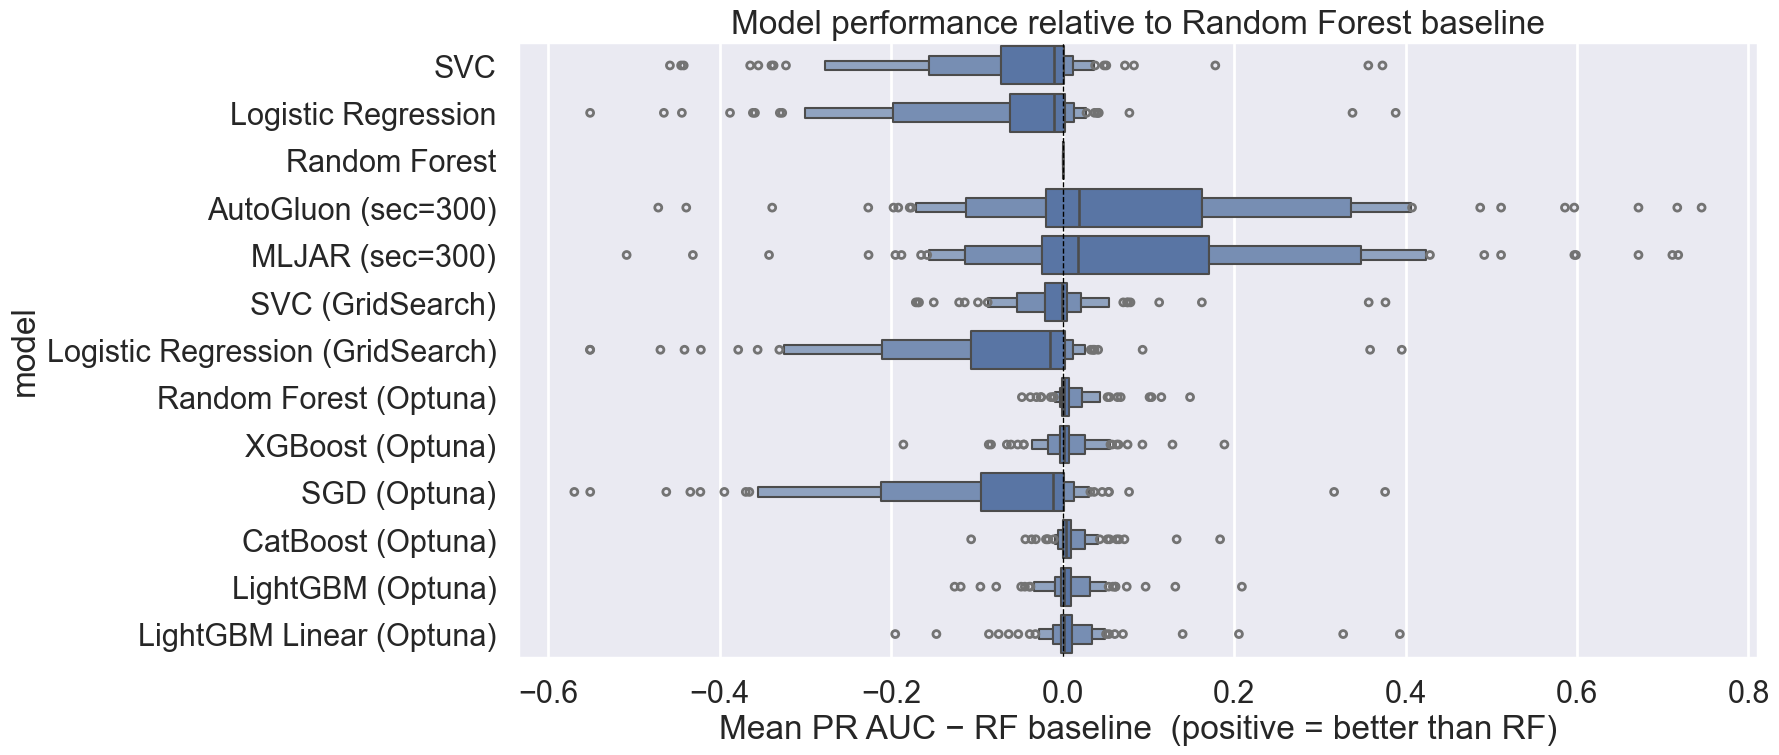

In [9]:
# distributions of delta PR AUC vs RF baseline
fig, ax = plt.subplots()
fig.set_size_inches(16, 8)
sns.boxenplot(data=results_df, x='mean_delta', y='model', ax=ax)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Mean PR AUC − RF baseline  (positive = better than RF)')
ax.set_title('Model performance relative to Random Forest baseline')


Text(121.21553466796875, 0.5, 'Mean PR AUC − RF baseline')

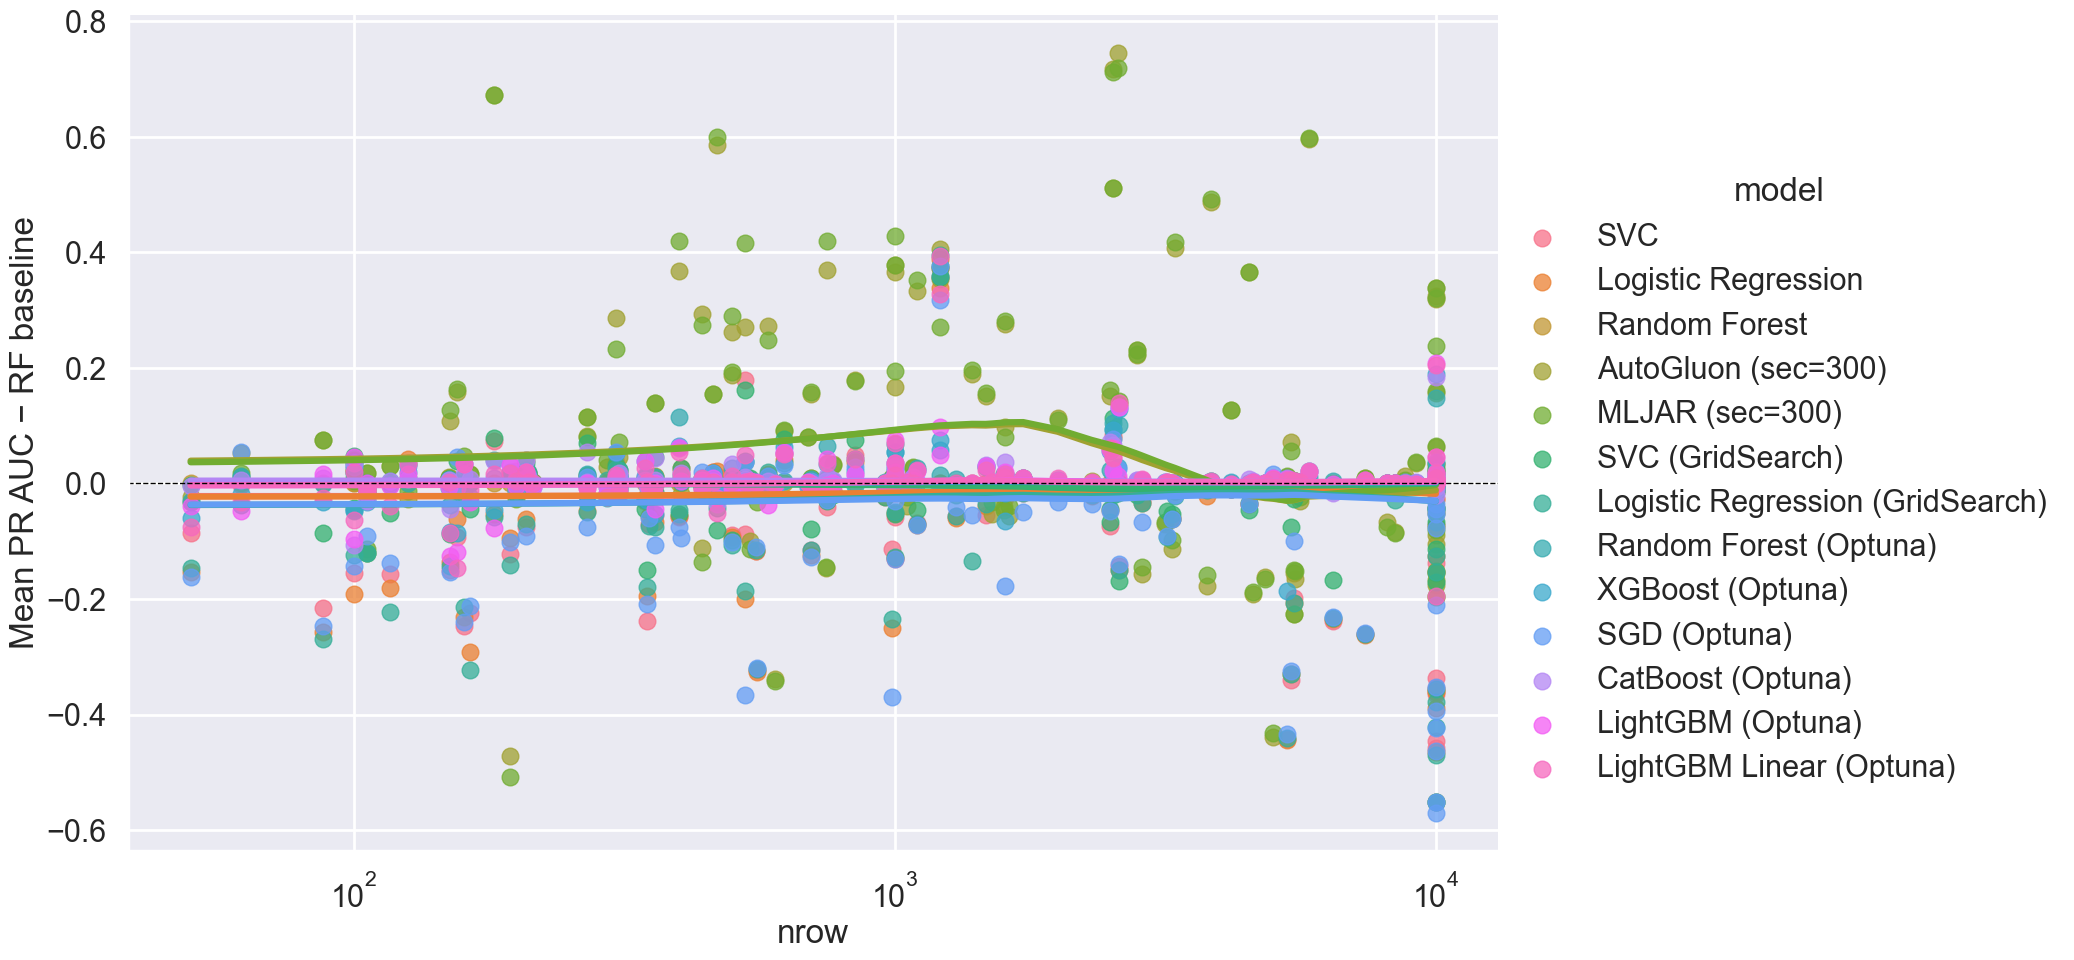

In [10]:
# delta PR AUC vs RF baseline vs number of samples in the data
g = sns.lmplot(
    data=results_df,
    x='nrow', y='mean_delta',
    hue='model',
    lowess=True,
    height=10,
    aspect=1.6,
    scatter_kws={'alpha': 0.75}
)
g.set(xscale='log')
g.ax.axhline(0, color='black', linestyle='--', linewidth=1)
g.ax.set_ylabel('Mean PR AUC − RF baseline')


Text(0.5, 1.0, 'Time-accuracy tradeoff')

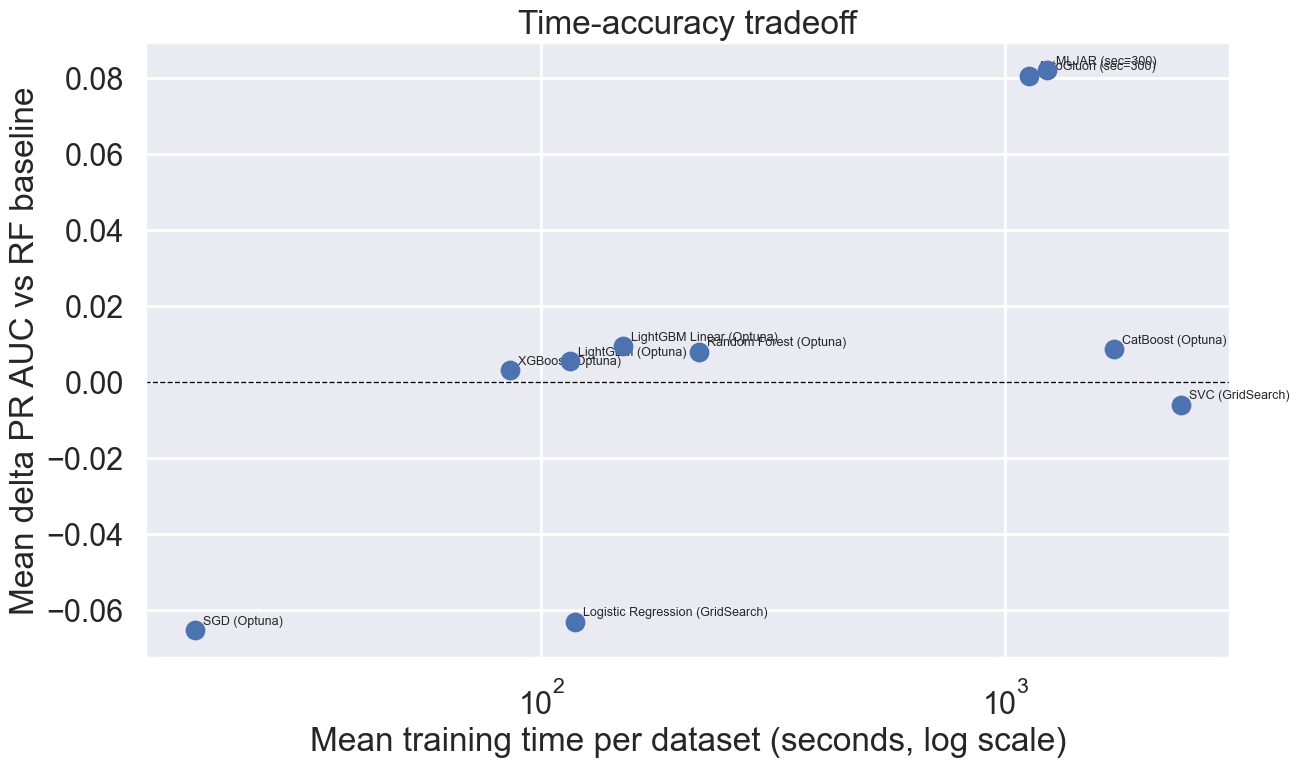

In [11]:
# Time-accuracy tradeoff
time_lookup = {}
for model_key, label in OPTUNA_MODEL_LABELS.items():
    if model_key in optuna_times and len(optuna_times[model_key]) > 0:
        time_lookup[label] = np.nanmean(optuna_times[model_key])
time_lookup['AutoGluon (sec=300)'] = np.nanmean(autogluon_times)
time_lookup['MLJAR (sec=300)'] = np.nanmean(mljar_times)

model_delta_mean = results_df.groupby('model')['mean_delta'].mean()
time_rows = []
for m, t in time_lookup.items():
    d = model_delta_mean.get(m, np.nan)
    time_rows.append({'model': m, 'mean_time_sec': t, 'mean_delta': d})
time_df = pd.DataFrame(time_rows).dropna()

fig, ax = plt.subplots(figsize=(14, 8))
ax.scatter(time_df['mean_time_sec'], time_df['mean_delta'], s=150, zorder=5)
for _, row in time_df.iterrows():
    ax.annotate(row['model'], (row['mean_time_sec'], row['mean_delta']),
                fontsize=9, xytext=(6, 4), textcoords='offset points')
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xscale('log')
ax.set_xlabel('Mean training time per dataset (seconds, log scale)')
ax.set_ylabel('Mean delta PR AUC vs RF baseline')
ax.set_title('Time-accuracy tradeoff')


Text(0.5, 1.0, 'Rank distribution across datasets')

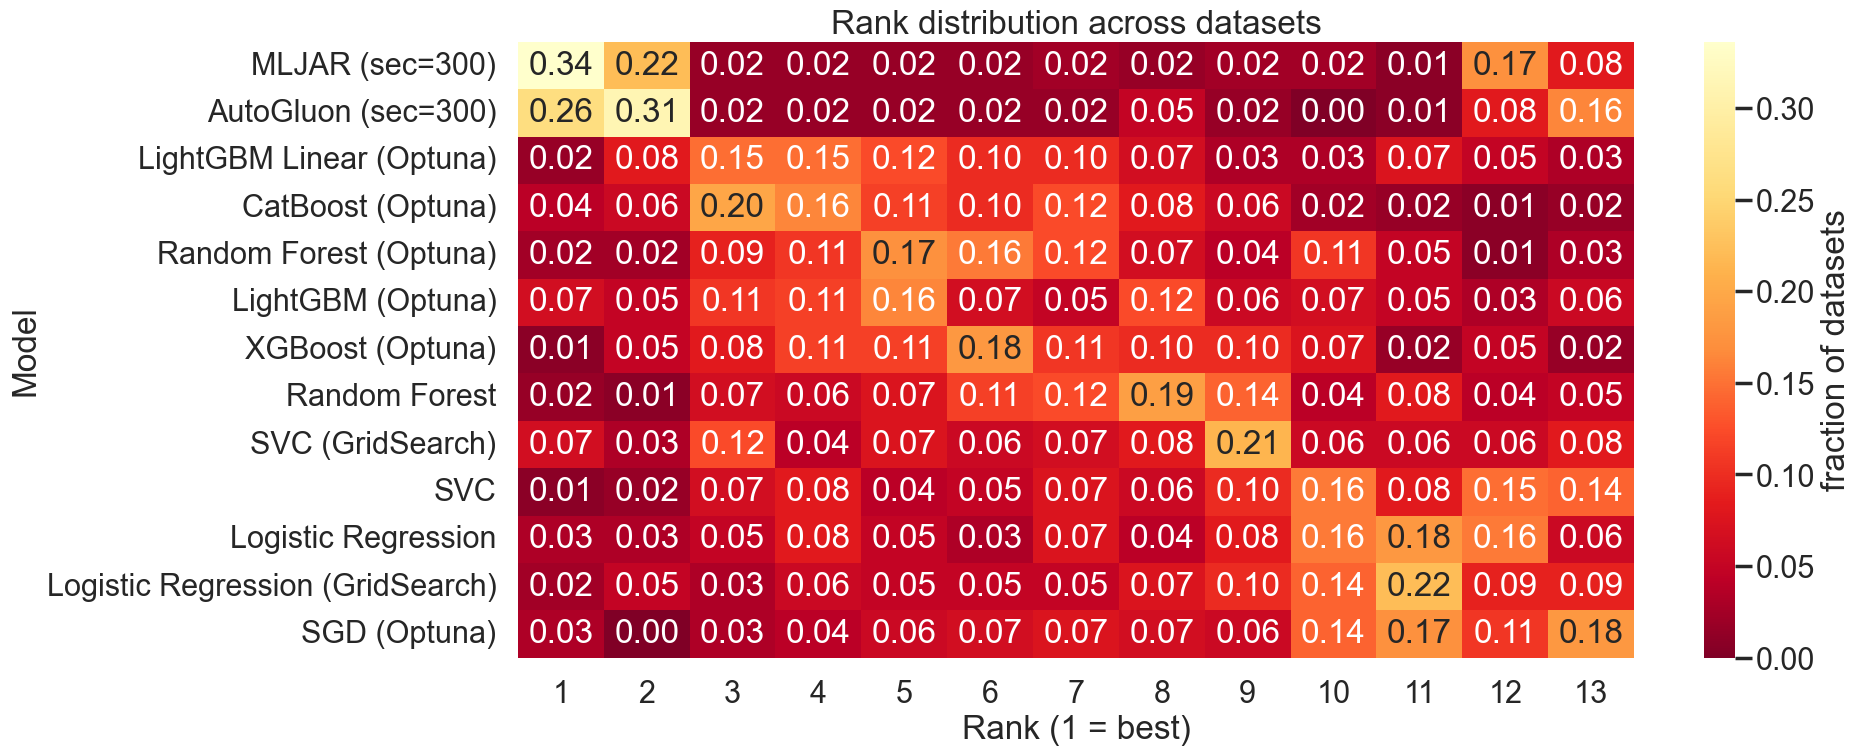

In [12]:
# Rank heatmap: fraction of datasets each model is rank k
pivot_full = results_df.pivot_table(index='dataset', columns='model', values='mean_prauc')
models_by_rank = results_df.groupby('model')['mean_delta'].mean().sort_values(ascending=False).index.tolist()
rank_pivot_full = pivot_full[models_by_rank].rank(axis=1, ascending=False, method='average')
n_ds = rank_pivot_full.notna().all(axis=1).sum()
rank_frac = pd.DataFrame(index=models_by_rank)
for r in range(1, len(models_by_rank) + 1):
    rank_frac[r] = (rank_pivot_full == r).sum() / n_ds

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(rank_frac, annot=True, fmt='.2f', cmap='YlOrRd_r', ax=ax,
            cbar_kws={'label': 'fraction of datasets'})
ax.set_xlabel('Rank (1 = best)')
ax.set_ylabel('Model')
ax.set_title('Rank distribution across datasets')


Text(120.9530932617187, 0.5, 'Std of delta PR AUC across folds')

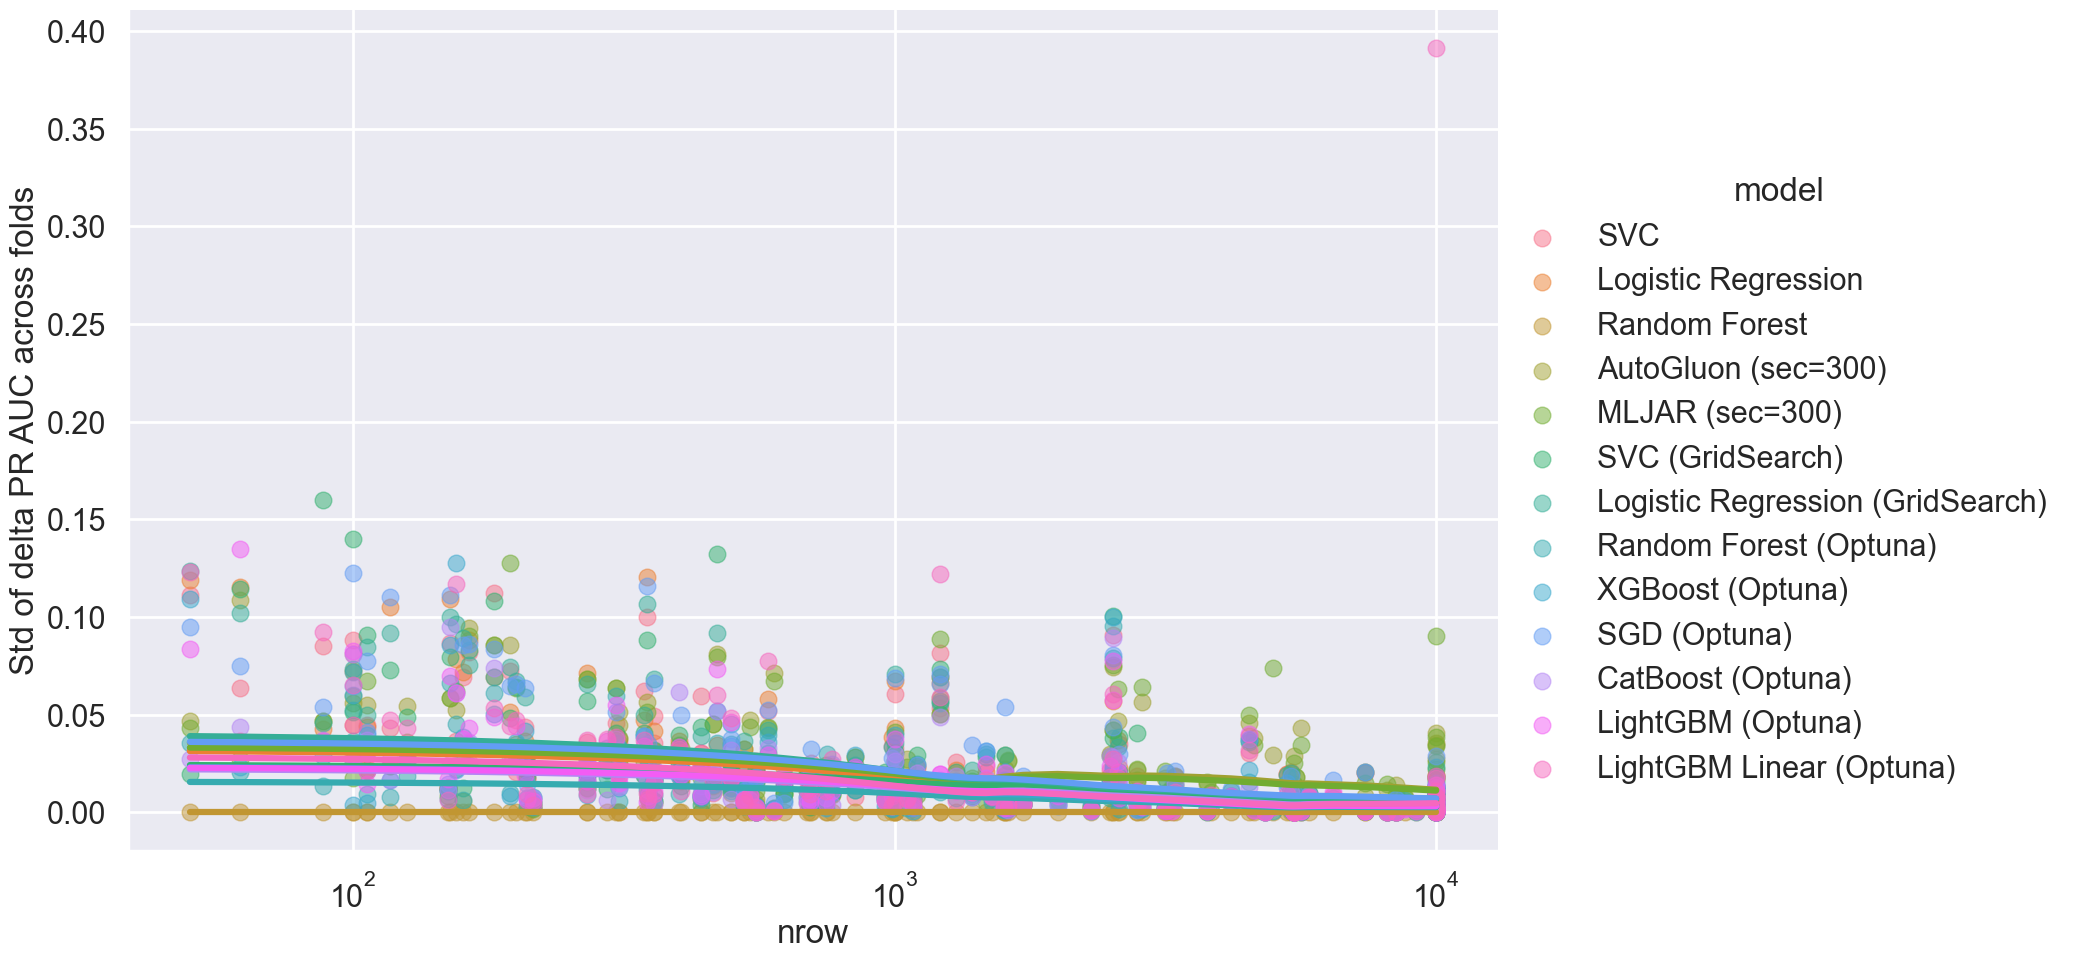

In [13]:
# variability of delta (across folds) vs number of samples
g = sns.lmplot(
    data=results_df,
    x='nrow', y='std_delta',
    hue='model',
    lowess=True,
    height=10,
    aspect=1.6,
    scatter_kws={'alpha': 0.5}
)
g.set(xscale='log')
g.ax.set_ylabel('Std of delta PR AUC across folds')


Text(121.21553466796875, 0.5, 'Mean delta PR AUC vs RF baseline')

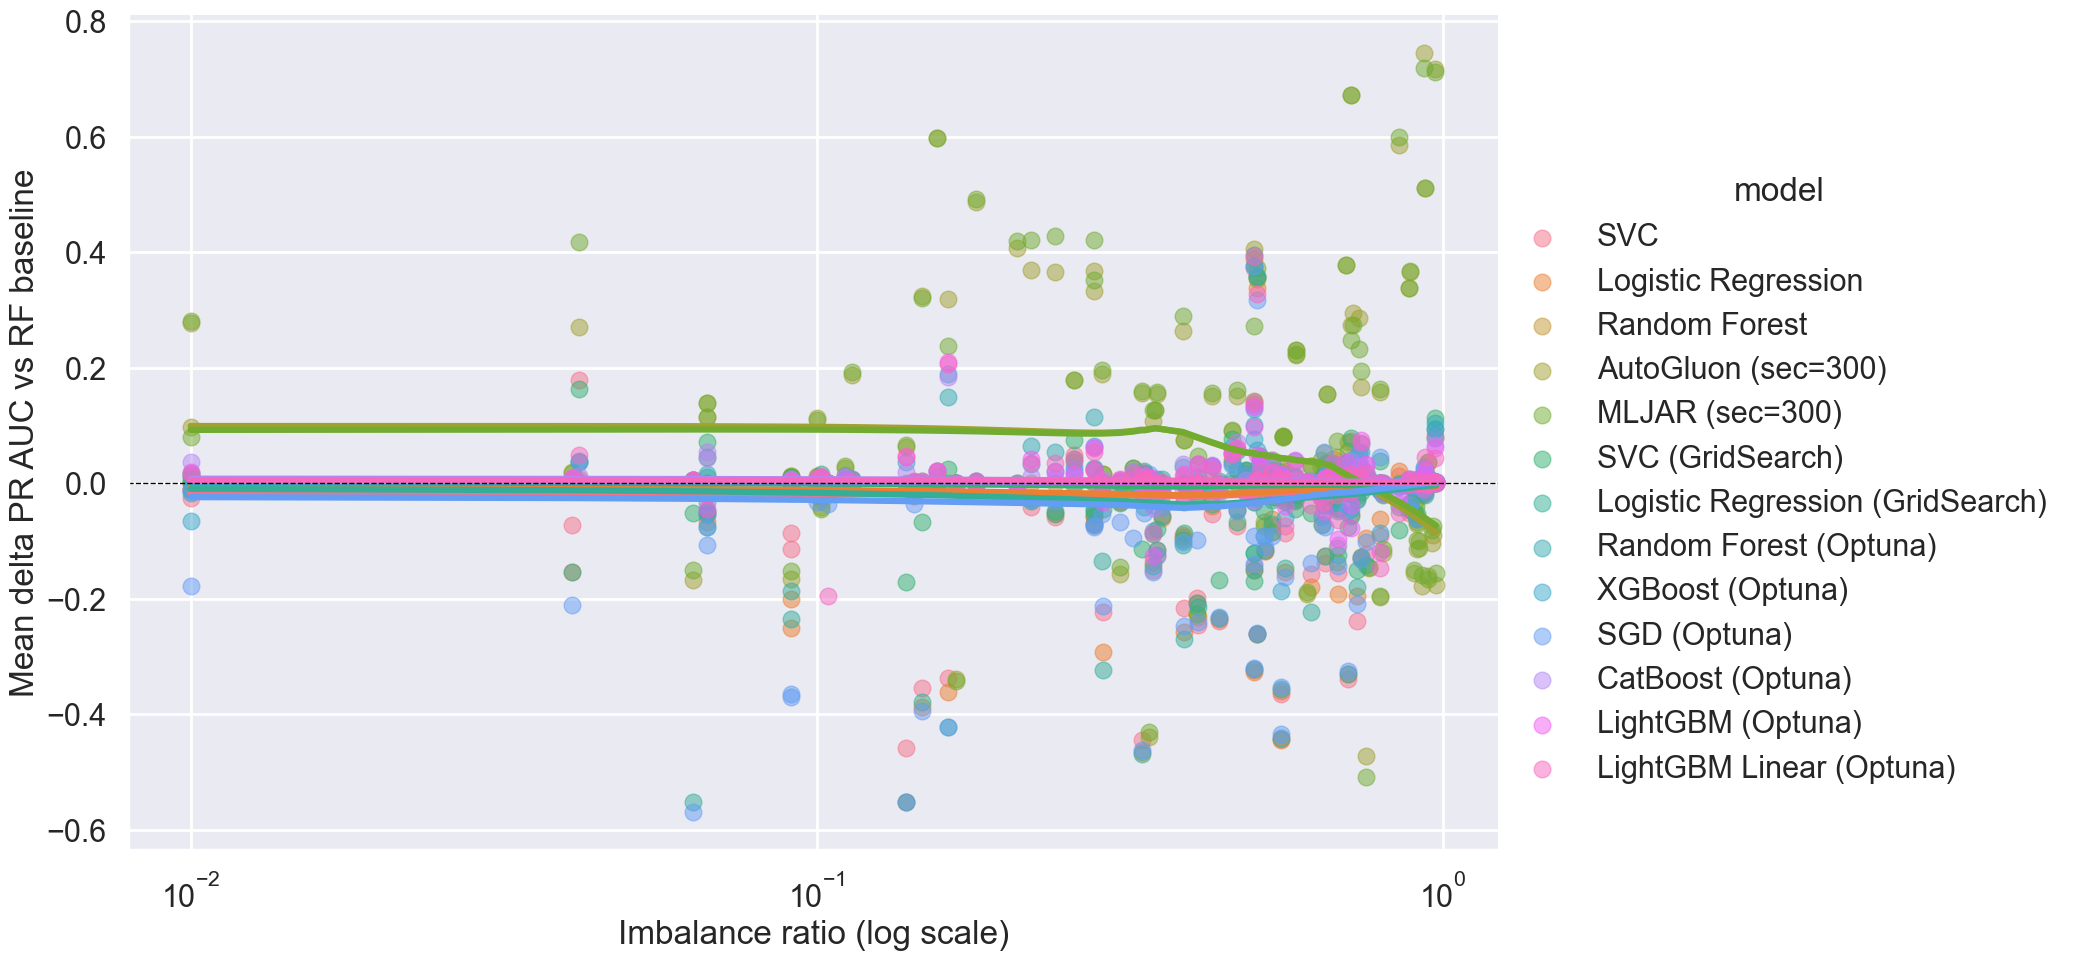

In [14]:
# delta PR AUC vs imbalance ratio
g = sns.lmplot(
    data=results_df,
    x='ir', y='mean_delta',
    hue='model',
    lowess=True,
    height=10,
    aspect=1.6,
    scatter_kws={'alpha': 0.5}
)
g.set(xscale='log')
g.ax.axhline(0, color='black', linestyle='--', linewidth=1)
g.ax.set_xlabel('Imbalance ratio (log scale)')
g.ax.set_ylabel('Mean delta PR AUC vs RF baseline')


Text(121.21553466796875, 0.5, 'Mean delta PR AUC vs RF baseline')

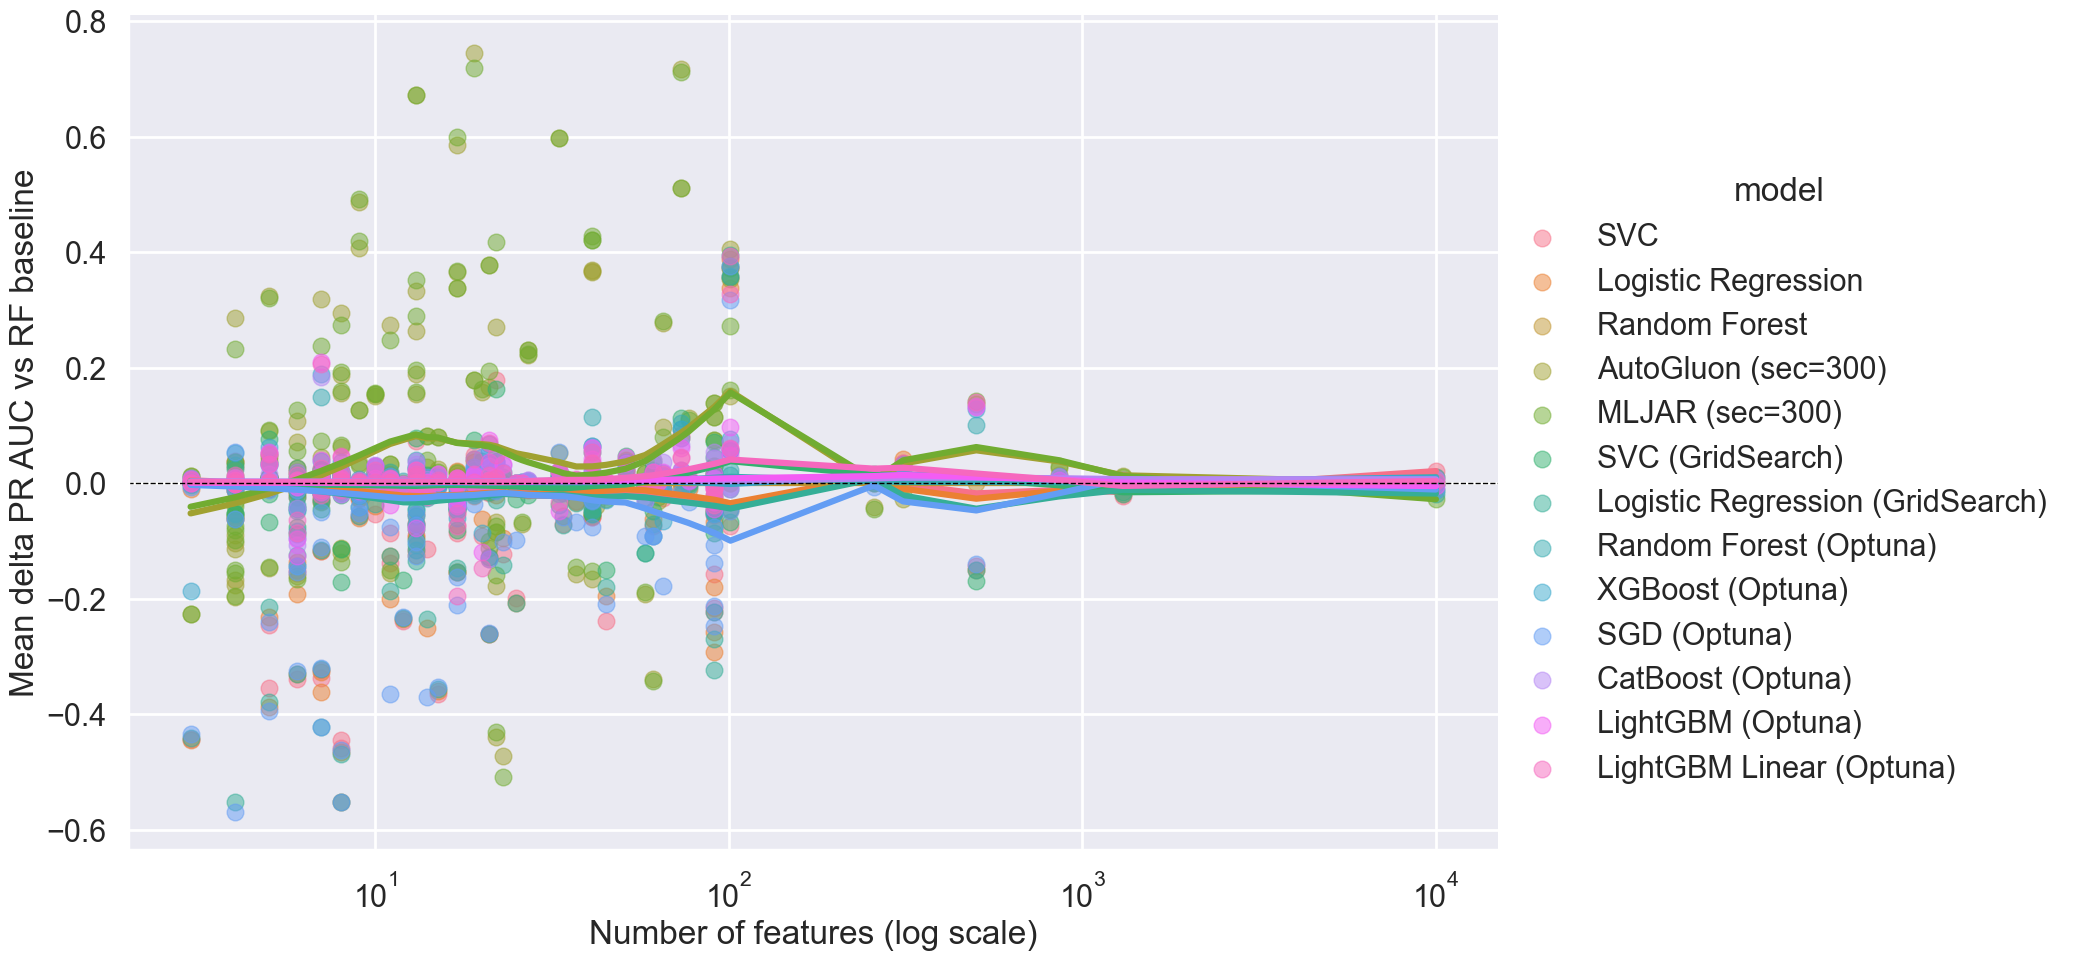

In [15]:
# delta PR AUC vs number of features
g = sns.lmplot(
    data=results_df,
    x='ncol', y='mean_delta',
    hue='model',
    lowess=True,
    height=10,
    aspect=1.6,
    scatter_kws={'alpha': 0.5}
)
g.set(xscale='log')
g.ax.axhline(0, color='black', linestyle='--', linewidth=1)
g.ax.set_xlabel('Number of features (log scale)')
g.ax.set_ylabel('Mean delta PR AUC vs RF baseline')


In [16]:
# datasets where there is a big gap between first largest and second largest performance
results_df.groupby('dataset')['mean_prauc'].apply(lambda x: np.sort(x)[-1] - np.sort(x)[-2]).sort_values()[-10:]

dataset
vertebra-column-2c                    0.027163
seismic-bumps                         0.027257
autoUniv-au1-1000                     0.027491
autoUniv-au6-250-drift-au6-cd1-500    0.050944
habermans-survival                    0.052916
autoUniv-au6-cd1-400                  0.053499
autoUniv-au6-1000                     0.062350
kr-vs-k                               0.080378
meta-data                             0.146657
plant-species-leaves-shape                 NaN
Name: mean_prauc, dtype: float64